In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'torch', 'torchvision', 'gymnasium']
imports = {'pillow': 'PIL'}
pinned = {'gymnasium': ('1.2.3', 'gymnasium[toy-text]==1.2.3', 'gymnasium[toy-text]==1.2.3', 'exact')}
fallbacks = {'torch': 'torch==2.11.0', 'torchvision': 'torchvision==0.26.0'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "0114bae219d4d94bc9d18a2e1ab76c089e2dc890"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/0114bae219d4d94bc9d18a2e1ab76c089e2dc890/d2l"
for name in ('__init__.py', 'torch.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Deep Q-Networks

A Deep Q-Network (DQN) replaces the tabular action-value function of Q-learning with a neural network [@mnih2013playing; @mnih2015human]. Unlike supervised regression, its bootstrapped targets depend on the function being trained. Consecutive transitions are correlated, and data in a replay buffer may have been collected by older policies. Together, function approximation, bootstrapping, and off-policy data can make value learning unstable.

DQN addresses two of these interactions with an experience-replay buffer and a target network. We introduce both mechanisms on CartPole, ablate the target network, and compare learned values with bounds implied by the task. The final part measures maximization bias and derives Double DQN, which separates action selection from evaluation.

In [1]:
%matplotlib inline
from d2l import torch as d2l
import gymnasium as gym
import numpy as np
import torch
from torch import nn
torch.set_num_threads(1)

We again use CartPole with discount $0.99$, but specify the training budget as $50{,}000$ environment steps because episode length changes as the policy improves. The agent takes one gradient step after every two environment steps. Its Q-network maps a state to one value per action, and the greedy action is the corresponding argmax.

In [2]:
gamma, num_env_steps, num_seeds = 0.99, 50_000, 3
buffer_size, batch_size, lr = 200_000, 128, 1e-3
train_freq, sync_every, warmup, grad_clip = 2, 250, 1_000, 10.0
epsilon = d2l.linear_schedule(1.0, 0.05, 10_000)
def make_qnet():
    return nn.Sequential(nn.Linear(4, 128), nn.ReLU(),
                         nn.Linear(128, 128), nn.ReLU(),
                         nn.Linear(128, 2))

## Sources of Instability

### The Semi-Gradient Update

Replace the table of that section by a network $Q_w$ and the update stays what it was, a semi-gradient step toward the bootstrapped target. Sample transitions $(s, a, r, s')$, form

$$y = r + \gamma\, \big(1 - \mathbf{1}(s' \textrm{ terminal})\big) \max_{a'} Q_w(s', a'),$$

hold $y$ fixed, and take one optimizer step on the regression loss between $Q_w(s,a)$ and $y$. Unlike the policy-gradient objective of that section, this is ordinary supervised regression. A decreasing loss shows that the network is fitting its current targets, but it does not show that those targets are accurate.

For a table, Q-learning is a stochastic approximation to the Bellman contraction analyzed in that section and that section. Function approximation adds a projection onto the functions represented by the network, weighted by the data's visitation distribution. The composition of this projection with the Bellman backup need not be a contraction. Even with linear features, the combination of bootstrapping and off-policy data can diverge [@Tsitsiklis.VanRoy.1997].

### Correlated Data

Consecutive transitions from one episode are strongly correlated: the cart and pole change only slightly from one step to the next. Training on this stream can repeatedly update a narrow region of state space. Because shared parameters change predictions at many states at once (the figure), these updates may degrade values learned elsewhere. A tabular method changes only the visited entry, so correlation mainly reduces sampling efficiency; with function approximation, it can also produce interference.

### Moving Targets

The second coupling is in the targets. The target $y$ contains $Q_w$, so every
optimizer step changes both the regressor and its target. In actor--critic, new
batches come from the current policy and may expose critic errors in the states
that policy visits, although this does not guarantee convergence. Replay instead
uses older transitions. A bootstrapping error can therefore persist across many
updates before the behavior policy revisits the affected states.

### The Deadly Triad

The three ingredients are *function approximation*, *bootstrapping*, and *off-policy data*. Figure the figure locates familiar algorithms by which ingredients they use. Removing function approximation gives tabular Q-learning, which converges under the conditions of that section. Removing bootstrapping gives neural REINFORCE with Monte Carlo targets and an unbiased policy gradient. Removing off-policy data gives methods such as SARSA and on-policy actor--critic.

These comparisons do not imply that every method using only two ingredients converges. Nonlinear on-policy temporal-difference learning can also diverge, and positive results require assumptions about step sizes, coverage, and representation. The term *deadly triad* refers to the particularly difficult combination of all three ingredients [@Sutton.Barto.2018; @vanHasselt.Doron.Strub.ea.2018].

Baird's counterexample isolates this combination in a seven-state linear problem [@Baird.1995]. Every reward is zero, so the true value function is zero and can be represented exactly by $w=0$. The experiment uses expected temporal-difference updates, eliminating sampling noise, but weights the seven states according to an off-policy distribution while evaluating a policy that always transitions to state seven:

sup norm of w after 0, 500, 1000 sweeps: 10, 77, 335
the value the weights claim for state 7: 677, true value 0


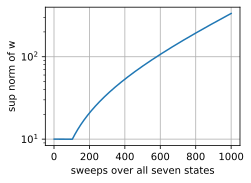

In [3]:
w = np.ones(8)                             # eight weights for seven states
w[6] = 10.0                                # the classic starting point
Phi = np.zeros((7, 8))                     # linear values v = Phi w
Phi[:6, :6], Phi[:6, 7] = 2 * np.eye(6), 1.0   # v(i) = 2 w_i + w_8
Phi[6, 6], Phi[6, 7] = 1.0, 2.0                # v(7) = w_7 + 2 w_8
sup = []
for _ in range(1000):
    v = Phi @ w                            # every reward is 0
    delta = gamma * v[6] - v               # the next state is always state 7
    w += 0.01 * (delta[:, None] * Phi).mean(0)   # uniform state weighting
    sup.append(np.abs(w).max())
print(f'sup norm of w after 0, 500, 1000 sweeps: 10, {sup[499]:.0f}, '
      f'{sup[-1]:.0f}')
print(f'the value the weights claim for state 7: {(Phi @ w)[6]:.0f}, '
      f'true value 0')
d2l.plot(np.arange(1, 1001), sup, 'sweeps over all seven states',
         'sup norm of w', yscale='log')

The weights grow approximately exponentially: after a thousand sweeps, their
sup norm has increased from $10$ to $335$, and the estimated value of state 7
is $677$ although its true value is zero. This deterministic expected-update
calculation has no sampling error, and reducing the step size slows but does not
remove the divergence. The cause is the composition of projection under the
off-policy weighting with a bootstrapped backup
[@Tsitsiklis.VanRoy.1997]. Reweighting the updates by the evaluated
policy's visitation distribution converges in this example (exercise 7).

Replay and target networks do not remove an element of the triad. They reduce
temporal correlation and slow target changes, which often improves empirical
stability but does not restore a general convergence guarantee.

![The deadly triad. Each circle is one ingredient, and every region is occupied by an algorithm these two chapters have taught; the center, all three ingredients at once, is where DQN and offline Q-learning live, and where Baird's counterexample proves that divergence is possible. Drop any one ingredient and convergence arguments become available again, each under its own step-size, coverage and representation conditions: the triad is a warning pattern, not an if-and-only-if theorem.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-rl-deadly-triad.svg)

## Replay and Target Networks

the figure draws the whole machine; the two subsections that follow walk its two ideas.

![Deep Q-learning as a data flow. The behavior policy acts with the online network; transitions enter the replay buffer, and uniformly sampled minibatches scramble time, which makes the data nearly independent and reusable. The regression target is computed by a frozen copy of the network, refreshed every $C$ steps, so the targets stand still between syncs. The gradient flows along exactly one path, into the online network; the marked edge from the frozen copy carries no gradient. The drawn buffer is full and evicting its oldest entries, the steady state of a long run; in this section's runs the 50,000-step budget never fills the 200,000-slot ring, so nothing is evicted.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-rl-dqn-dataflow.svg)

### Experience Replay and Off-Policy Updates

The standard remedy for temporal correlation is an *experience replay buffer* [@Lin.1992]. Transitions are stored in a finite array, and training minibatches are sampled uniformly from that array. A minibatch therefore combines transitions collected at different times, and each transition may be used in several updates. This is valid for Q-learning because the target for $(s,a,r,s')$ does not depend on the policy that selected $a$. The same property will be central to the distinction between on-policy and off-policy learning in that section.

In [4]:
class ReplayBuffer:
    """A ring of transitions in preallocated numpy; sample() returns a Batch."""
    def __init__(self, capacity, obs_dim):
        self.obs = np.zeros((capacity, obs_dim), np.float32)
        self.act = np.zeros(capacity, np.int64)
        self.rew = np.zeros(capacity, np.float32)
        self.next_obs = np.zeros((capacity, obs_dim), np.float32)
        self.term = np.zeros(capacity, np.float32)
        self.capacity, self.size, self.ptr = capacity, 0, 0

    def add(self, obs, act, rew, next_obs, term):
        i = self.ptr
        self.obs[i], self.act[i], self.rew[i] = obs, act, rew
        self.next_obs[i], self.term[i] = next_obs, term
        self.ptr, self.size = (i + 1) % self.capacity, min(self.size + 1,
                                                           self.capacity)

    def __len__(self):
        return self.size

    def sample(self, batch_size, rng):
        i = rng.integers(self.size, size=batch_size)
        return d2l.Batch(self.obs[i], self.act[i], self.rew[i],
                         self.next_obs[i], self.term[i],
                         np.array([batch_size]))

Two details of the container matter. Its capacity is $200{,}000$ transitions, larger than the $50{,}000$-step training budget, so no transition is evicted in these experiments; exercise 4 studies a smaller buffer. In addition, `sample` returns a `Batch` without episode structure. Consequently, `reward_to_go` and `gae` are not defined for such a batch, whereas `td_target` requires only individual transitions. This is why replay combines naturally with one-step bootstrapping. The target below is the same `batch.td_target` used by the actor-critic critic.

### The Target Network

The repair for moving targets is the *target network* [@mnih2015human]: a frozen copy $Q_{w^-}$ of the online network computes every bootstrap,

$$y = r + \gamma\, \big(1 - \mathbf{1}(s' \textrm{ terminal})\big) \max_{a'} Q_{w^-}(s', a'),$$

and synchronize the copy with the online weights, $w^-\leftarrow w$, every $C$ steps, here every 250. Between synchronizations, the target is fixed and the online network solves an ordinary regression problem. The feedback from predictions to targets now occurs once per synchronization rather than once per gradient step. The actor--critic method in that section updates its target from the newest critic because each batch contains fresh on-policy data. Replay removes that freshness, so DQN instead accepts stale targets to reduce the rate at which the regression problem changes.

The regression update uses two distinct controls. The Huber loss is quadratic near zero and linear for large residuals, so it bounds the derivative of the loss with respect to the prediction. The parameter gradient also contains $\nabla_w Q_w(s,a)$, which the Huber loss does not bound. Global norm clipping therefore limits the complete parameter update, including the large simultaneous residual changes that may follow a target-network synchronization.

In [5]:
def q_values(qnet, obs):
    """The acting forward: numpy in, numpy out, no gradient recorded."""
    with torch.inference_mode():
        return qnet(torch.as_tensor(obs)).numpy()

def fit_q(qnet, opt, batch, y):
    """One clipped Huber regression step of Q_w(s, a) toward the fixed y."""
    pred = qnet(torch.as_tensor(batch.obs)).gather(
        -1, torch.as_tensor(batch.act)[:, None]).squeeze(-1)
    loss = nn.functional.huber_loss(pred, torch.as_tensor(y))
    opt.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(qnet.parameters(), grad_clip)
    opt.step()

def q_step(qnet, target, opt, batch):
    """The DQN update: the critic's own td_target, bootstrapped by the copy."""
    fit_q(qnet, opt, batch, batch.td_target(
        lambda s: q_values(target, s).max(-1), gamma))

One hairline detail separates the two tabs. The pytorch update literally calls `batch.td_target`, the structural thesis in a single line; the jax update runs a couple of hundred thousand times and is compiled, and a compiled function cannot call back into a numpy method, so it computes the same expression inline (that section). The next cell certifies that "the same expression" is not a figure of speech, on a buffer filled by a random policy through the `rollout` helper both chapters share:

In [6]:
rng, env = np.random.default_rng(0), gym.make('CartPole-v1')
env.reset(seed=0)
data = d2l.rollout(env, lambda s, r: int(r.integers(2)), 20, rng)
buffer = ReplayBuffer(buffer_size, 4)
for i in range(len(data)):
    buffer.add(data.obs[i], data.act[i], data.rew[i],
               data.next_obs[i], data.term[i])
b = buffer.sample(batch_size, rng)
torch.manual_seed(0)
tnet = make_qnet()
with torch.inference_mode():
    y = (torch.as_tensor(b.rew) + gamma * (1 - torch.as_tensor(b.term))
         * tnet(torch.as_tensor(b.next_obs)).max(-1).values).numpy()
print(np.allclose(y, b.td_target(lambda s: q_values(tnet, s).max(-1), gamma)))

True


Now the training loop, and it is short because everything it needs already exists: `epsilon_greedy` and `linear_schedule` from that section, the buffer and step above. One switch controls the experiment of this section. With `use_target=True` the copy refreshes every `sync_every` steps; with `use_target=False` it refreshes every step, which makes the copy the online network in all but name, the naive recipe with no target network at all. The generator yields, at every episode's end, the step count, the episode's return, and one diagnostic we will need later: the network's value estimate $\max_a Q_w(s_0, a)$ at the centered start state $s_0 = \mathbf{0}$.

In [7]:
def train_dqn(seed, qnet, use_target=True, step=None):
    """DQN on CartPole; yields (env step, episode return, max_a Q(s0, a))."""
    step = q_step if step is None else step
    rng, env = np.random.default_rng(seed), gym.make('CartPole-v1')
    target = make_qnet()
    target.load_state_dict(qnet.state_dict())
    opt = torch.optim.Adam(qnet.parameters(), lr=lr)
    buffer, s0 = ReplayBuffer(buffer_size, 4), np.zeros(4, np.float32)
    obs, ep_return = env.reset(seed=seed)[0], 0.0
    sync = sync_every if use_target else 1
    for t in range(1, num_env_steps + 1):
        a = d2l.epsilon_greedy(q_values(qnet, obs), epsilon(t), rng)
        next_obs, rew, terminated, truncated, _ = env.step(a)
        buffer.add(obs, a, rew, next_obs, float(terminated))
        obs, ep_return = next_obs, ep_return + rew
        if terminated or truncated:
            yield t, ep_return, q_values(qnet, s0).max()
            obs, ep_return = env.reset()[0], 0.0
        if len(buffer) >= warmup and t % train_freq == 0:
            step(qnet, target, opt, buffer.sample(batch_size, rng))
        if t % sync == 0:
            target.load_state_dict(qnet.state_dict())

Note what the buffer stores: `terminated`, never `truncated`. A CartPole episode cut off at 500 steps ends in a state with a future, and that section established that masking the bootstrap there teaches the network that surviving is worthless; exercise 2 traces exactly what would go wrong.

### Ablating the Target Network

Three seeds per arm, everything identical except the switch. The networks are caller-owned, as in that section, so later cells can audit the trained agents:

In [8]:
def new_qnet(seed):
    torch.manual_seed(seed)
    return make_qnet()
arms = ('DQN', 'no target network')
qnets = {arm: [new_qnet(seed) for seed in range(num_seeds)] for arm in arms}
runs = {arm: [list(train_dqn(seed, qnets[arm][seed],
                             use_target=arm == 'DQN'))
              for seed in range(num_seeds)] for arm in arms}

Each run yields one tuple per episode, and seeds finish different numbers of episodes, so the right x axis is the one the budget is written in. We resample every curve onto a common grid of environment steps and plot the seed bands:

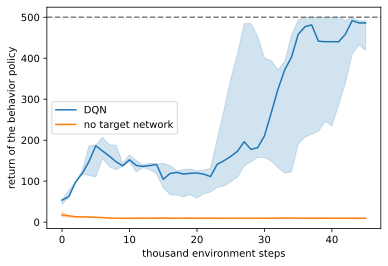

In [9]:
grid = np.arange(1, num_env_steps // 1000 + 1) * 1000

def on_grid(arm, col):
    """Resample each seed's per-episode series onto the env-step grid."""
    return np.stack([np.interp(grid, np.asarray(r)[:, 0], np.asarray(r)[:, col])
                     for r in runs[arm]])

d2l.plot_curves({arm: on_grid(arm, 1) for arm in runs},
                xlabel='thousand environment steps',
                ylabel='return of the behavior policy', smooth=5,
                reference=500)

The two variants differ only in whether the bootstrap uses a target network. With a target network, every seed improves from the random policy's return of about 20, although learning remains variable and no seed remains at the maximum return of 500. The behavior-policy curve cannot reach 500 consistently because the final exploration rate is $\epsilon=0.05$, which forces a random action on approximately one step in twenty. Without a target network, returns improve briefly and then collapse for every seed in both framework implementations. The online network then supplies its own changing targets, and the poor greedy policy collects data that reinforces the same estimates. The separate greedy evaluation below removes exploratory actions from the comparison.

Because the return keeps falling off its peaks and climbing back, the summary statistic you choose matters more than it should, and the next cell computes the candidates rather than asserting them. For each seed we take every trailing 20-episode average the run contains, and report the best one, the final one, and the one the run would have reported had we stopped it fifty episodes earlier:

In [10]:
def windows(returns, k=20):
    """All trailing k-episode averages of a run, in order."""
    return np.convolve(returns, np.ones(k) / k, 'valid')

for arm in runs:
    w = [windows(np.asarray(r)[:, 1]) for r in runs[arm]]
    best = np.array([x.max() for x in w])
    final = np.array([x[-1] for x in w])
    early = np.array([x[-51] for x in w])
    print(f'{arm:>18}: best 20-episode window per seed {np.round(best)}\n'
          f'{"":>18}  final window {np.round(final)} '
          f'(spread {np.ptp(final):.0f})\n'
          f'{"":>18}  fifty episodes earlier {np.round(early)}')

               DQN: best 20-episode window per seed [500. 348. 457.]
                    final window [496. 348. 431.] (spread 148)
                    fifty episodes earlier [163.  99. 203.]
 no target network: best 20-episode window per seed [30. 27. 25.]
                    final window [9. 9. 9.] (spread 0)
                    fifty episodes earlier [10. 10. 10.]


The final-window return varies by more than one hundred points across seeds,
and the value fifty episodes earlier differs again. It therefore describes the
state of each training run at the stopping time rather than a stable endpoint.
Selecting the best window after observing the entire curve introduces
optimistic selection bias; reporting its seed spread does not remove that bias.

For evaluation, we predeclare a budget of $50{,}000$ environment steps and
then evaluate the resulting policy separately. This separates the policy from
the exploration noise in the training return and avoids choosing a stopping
point after inspecting the curves.

The behavior return combines policy quality with the effect of $\epsilon$-greedy exploration. After the fixed training budget, we therefore evaluate the greedy policy separately with $\epsilon=0$:

In [11]:
env = gym.make('CartPole-v1')
for arm in arms:
    for seed in range(num_seeds):
        env.reset(seed=100 + seed)
        qnet = qnets[arm][seed]
        score = d2l.evaluate(env, lambda s, r: int(q_values(qnet, s).argmax()),
                             num_episodes=100)
        print(f'{arm:>18}, seed {seed}: greedy return over 100 episodes '
              f'{score:.0f}')

               DQN, seed 0: greedy return over 100 episodes 500


               DQN, seed 1: greedy return over 100 episodes 93


               DQN, seed 2: greedy return over 100 episodes 500
 no target network, seed 0: greedy return over 100 episodes 10
 no target network, seed 1: greedy return over 100 episodes 9


 no target network, seed 2: greedy return over 100 episodes 9


Without exploratory actions, some seeds achieve the maximum return of 500, while others score far below their recent behavior returns. The final greedy policy is a single snapshot of an oscillatory training process, so evaluation depends on the point at which training stops. Across frameworks and seeds, the greedy returns range from roughly 90 to 500. Every run without a target network fails almost immediately.

To distinguish value instability from policy instability, the training loop records $\max_a Q_w(s_0,a)$ at the centered start state. The code masks bootstrapping only on `terminated`; it continues to bootstrap across the 500-step time limit, and the state contains no time coordinate. It therefore learns the continuing-task value in which the time limit ends data collection but not the underlying process.

In this formulation, a policy that balances the pole indefinitely has value $1/(1-\gamma)=100$ from the start. The dashed line marks this ceiling:

continuing-task ceiling: 100; the no-target arm ends at 1e+08, 1e+08, 1e+08


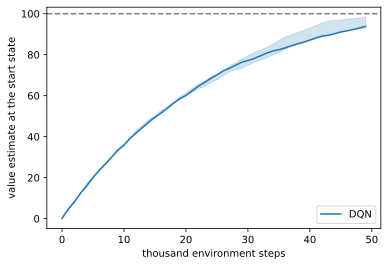

In [12]:
ceiling = 1 / (1 - gamma)
d2l.plot_curves({'DQN': on_grid('DQN', 2)},
                xlabel='thousand environment steps',
                ylabel='value estimate at the start state',
                reference=ceiling)
print(f'continuing-task ceiling: {ceiling:.0f}; the no-target arm ends at ' +
      ', '.join(f'{np.asarray(r)[-1, 2]:.0e}' for r in
                runs['no target network']))

For DQN, the recorded start-state estimate remains within tens of points of the continuing-task ceiling across frameworks and seeds. The corresponding return curves still oscillate because small changes in action values can change the greedy action and produce a substantially different policy. This trace concerns only $s_0$ and does not certify that every Q-value is stable or accurate.

The scale nevertheless separates the two ablations. DQN ends near $10^2$, whereas the version without a target network exceeds $10^8$. The latter clearly diverges. Some DQN seeds settle above the ceiling of 100. Since no policy can exceed that value under the objective implemented here, those estimates demonstrate overestimation.

The next experiment isolates the maximization bias that produces this effect.

## Overestimation

### Measuring the Maximization Bias

The target the equation maximizes estimated action values. For noisy estimates, $E[\max_{a'}\hat{Q}(s',a')]\geq\max_{a'}E[\hat{Q}(s',a')]$, with strict inequality when noise can change the maximizing action. that section demonstrated this bias in a table, and that section showed that the hard maximum is the $\beta\to0$ limit of the soft backup. Function approximation can feed the resulting bias back into subsequent targets [@Thrun.Schwartz.1993].

The following simulation gives four actions the same true value of zero and adds independent unit noise to each estimate. The single estimator selects and evaluates an action with the same noisy values. The double estimator selects with one set of noisy values and evaluates with an independent set [@vanHasselt.2010]:

In [13]:
rng = np.random.default_rng(0)
est = rng.standard_normal((100_000, 4))     # four values, all truly zero
second = rng.standard_normal((100_000, 4))  # an independent second estimate
sel = est.argmax(1)
print(f'single estimator, E[max of the estimates]: {est.max(1).mean():.3f}')
print(f'select with one, evaluate with the other: '
      f'{second[np.arange(100_000), sel].mean():+.3f}')

single estimator, E[max of the estimates]: 1.031
select with one, evaluate with the other: -0.006


The maximum of four unit-noise estimates has about one unit of upward
bias. With independent selection and evaluation estimates, the evaluator's
noise has zero conditional mean for the selected action, and the measured
bias is near zero. the figure shows that the single-estimator
bias grows with the number of actions while the independent double
estimator remains near zero. In DQN, shared parameters and bootstrapping
can propagate this bias to other states; a fixed offline dataset also
removes the corrective effect of new interaction (that section).

![A maximum over noisy estimates is biased upward. Left: the distribution of the largest of four independent estimates of the same true value of zero, against the distribution of a single estimate; the maximum carries a measured bias of $1.03$. Right: the bias of the single estimator grows with the number of actions, while the double estimator, one set of estimates selecting the action and an independent set scoring it, stays below $0.002$ in magnitude throughout.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-rl-max-bias.svg)

### Double DQN

The double estimator requires two value estimates, and DQN already maintains an online network and a target network. Double DQN uses the online network to select the action and the target network to evaluate it [@Hasselt.Guez.Silver.2016]:

$$y = r + \gamma\, \big(1 - \mathbf{1}(s' \textrm{ terminal})\big)\ Q_{w^-}\big(s',\ \underset{a'}{\mathrm{argmax}}\ Q_w(s', a')\big).$$

An action selected by an overestimate in the online network is therefore
not evaluated by that same output. The target copy is correlated with the
online network, so Double DQN only approximates the independent double
estimator analyzed above. It reuses the two forward passes already
required by DQN; the change to `q_step` is three lines:

In [14]:
def q_step_double(qnet, target, opt, batch):
    """q_step with selection split from evaluation, eq_double_dqn."""
    sel = q_values(qnet, batch.next_obs).argmax(-1)
    fit_q(qnet, opt, batch, batch.td_target(
        lambda s: q_values(target, s)[np.arange(len(s)), sel], gamma))

The training loop changes only the update function; data collection, replay,
target synchronization, and evaluation remain fixed. We use the same logged
diagnostic for the comparison:

In [15]:
qnets['Double DQN'] = [new_qnet(seed) for seed in range(num_seeds)]
runs['Double DQN'] = [list(train_dqn(seed, qnets['Double DQN'][seed],
                                     step=q_step_double))
                      for seed in range(num_seeds)]

       DQN: final value estimate at s0, per seed: [93.8 98.3 93. ]
Double DQN: final value estimate at s0, per seed: [92.6 95.1 91. ]


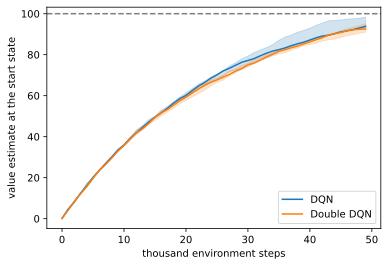

In [16]:
d2l.plot_curves({arm: on_grid(arm, 2) for arm in ('DQN', 'Double DQN')},
                xlabel='thousand environment steps',
                ylabel='value estimate at the start state',
                reference=ceiling)
for arm in ('DQN', 'Double DQN'):
    print(f'{arm:>10}: final value estimate at s0, per seed: '
          f'{np.round([np.asarray(r)[-1, 2] for r in runs[arm]], 1)}')

The Double DQN estimates usually end a few points below the DQN estimates, with the largest reductions in seeds that had moved furthest above the ceiling. Their seed bands overlap during most of training. CartPole has only two actions, and the figure shows that maximization bias grows with the number of actions. The effect is therefore expected to be small here.

On Atari, with as many as eighteen actions, Double DQN changes scores substantially [@Hasselt.Guez.Silver.2016]. The same distinction becomes important in offline learning, where inflated actions cannot be corrected by new interaction (that section). At this CartPole budget, any difference in return remains within variation across seeds.

## The DQN Lineage

### Extensions and Successors

Several later methods modify individual components of DQN. An $n$-step target uses several observed rewards before bootstrapping, as developed in that section. Prioritized replay samples transitions according to their temporal-difference error rather than uniformly [@Schaul.Quan.Antonoglou.ea.2016]; its advantage decreases as replay buffers become larger and more diverse. A dueling network represents $Q$ as a state value plus action advantages [@Wang.Schaul.Hessel.ea.2016].

Distributional methods estimate the return distribution rather than only its mean [@Bellemare.Dabney.Munos.2017]. In tabular and linear settings, their expected update for the mean coincides with the ordinary update, so their empirical benefit depends on the interaction with nonlinear function approximation. Rainbow combines six extensions and reports an ablation of their individual contributions [@Hessel.Modayil.vanHasselt.ea.2018].

PQN provides a contrasting design: with LayerNorm and batches collected from parallel environments, deep Q-learning can train without a replay buffer or target network [@Gallici.Fellows.Ellis.ea.2025]. Replay and target networks are therefore one solution to correlated data and moving targets, not necessary components of every stable deep Q-learning system.

### DQN in Modern Practice

Vanilla DQN is mainly useful here as a simple setting in which to study two problems of deep value learning: moving bootstrap targets and maximization bias. It also establishes how a learner can use transitions collected by a different policy. Since the policy requires an argmax over actions, the basic method is restricted to discrete action spaces; actor-based methods extend related ideas to continuous control. that section considers the limiting case in which all learning uses a fixed dataset and no further interaction is allowed.

## Summary

With function approximation, bootstrapping, and off-policy data, Q-learning can diverge even when the value class contains the correct solution. Experience replay reduces temporal correlation and reuses transitions, while a target network holds bootstrap targets fixed between updates. These mechanisms improve stability but do not restore the tabular convergence theorem. DQN also inherits maximization bias. Double DQN reduces this bias by selecting an action with the online network and evaluating it with the target network.

**Experimental scope.** Baird's counterexample and the synthetic maximization-bias calculation are deterministic. The CartPole ablation uses three seeds per method and framework for $50{,}000$ environment steps. Every run without a target network diverges beyond $10^8$ in value, while the target-network runs learn but remain variable. Fixed-budget greedy evaluation is reported separately from exploratory training return. At two actions, the effect of Double DQN on return is smaller than the variation across runs.

## Exercises

1. [conceptual] *What survives the scramble.* A batch sampled from
   `ReplayBuffer` carries a fake episode boundary. For each of
   `td_target`, `reward_to_go`, and `gae`, state whether its value on such a
   batch is meaningful, and connect the pattern to the on-policy/off-policy
   split: why is the estimator that survives the scramble exactly the one
   whose target ignores the collector?
1. [conceptual] *Terminated, not done.* The buffer stores `float(terminated)`
   and never `truncated`. Recalling that section's masking
   discussion, describe precisely what the targets would teach the network
   about long CartPole episodes if `done` were stored instead, and why the
   damage would grow as the policy improves.
1. [short-code] *The sync period.* Rerun the target arm with
   `sync_every` in $\{50, 250, 2500\}$, one seed each. Distinguish two
   failure directions: does the bad end merely slow learning, or does it cap
   what the run reaches within the budget? Report fixed-budget greedy
   evaluations, with the best and final windows beside them as descriptions
   of the curve, and say why the distinction matters here of all places.
1. [short-code] *Shrink the buffer.* Set the capacity to 500 transitions and
   retrain one seed. Which of the two couplings does this reintroduce, what
   do the return curve and the $\max_a Q_w(s_0, a)$ trace look like, and why
   does the failure wait until the policy is good before it arrives?
1. [short-code] *Best against final, at scale.* Using only curves already
   logged by this section's cells and exercise 3's runs, no new training,
   collect the best-window and final-window statistics across every seed and
   arm. Which spread is a property of the algorithm and which is mostly a
   property of when you stopped looking, and why does a predeclared
   fixed-budget evaluation belong in a paper where neither window does?
1. [short-code] *Port it.* Move the section's code to `LunarLander-v3`.
   List every line that changes and every line that does not, then explain
   why the step budget is the one number you should expect to raise
   substantially. (Running the port to a strong policy takes roughly ten
   times this section's budget; the listing question is answerable without
   running at all.)
1. [extended] *Baird, with a target network.* Add a target network to the
   Baird cell: compute every $\delta$ from a frozen copy of $w$, synced every
   $k$ sweeps, for $k \in \{10, 100\}$. Does the iteration now converge,
   diverge more slowly, or diverge the same? Which corner of the triad did
   the target network actually remove, and what does the answer say about
   what DQN's second repair can and cannot buy?

[Discussions](https://d2l.discourse.group/)